<>:49: SyntaxWarning: invalid escape sequence '\p'
<>:52: SyntaxWarning: invalid escape sequence '\l'
<>:49: SyntaxWarning: invalid escape sequence '\p'
<>:52: SyntaxWarning: invalid escape sequence '\l'
/var/folders/by/4bp_bx4j7mqfwpptj2_7zwzw0000gn/T/ipykernel_40499/3309948747.py:49: SyntaxWarning: invalid escape sequence '\p'
  plt.step(bins[:-1], counts, color=colors[idx], label=f'$\phi$={phi:.2f}', where='mid', lw=2)
/var/folders/by/4bp_bx4j7mqfwpptj2_7zwzw0000gn/T/ipykernel_40499/3309948747.py:52: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$z = (E - \langle E \\rangle) / \sigma$')


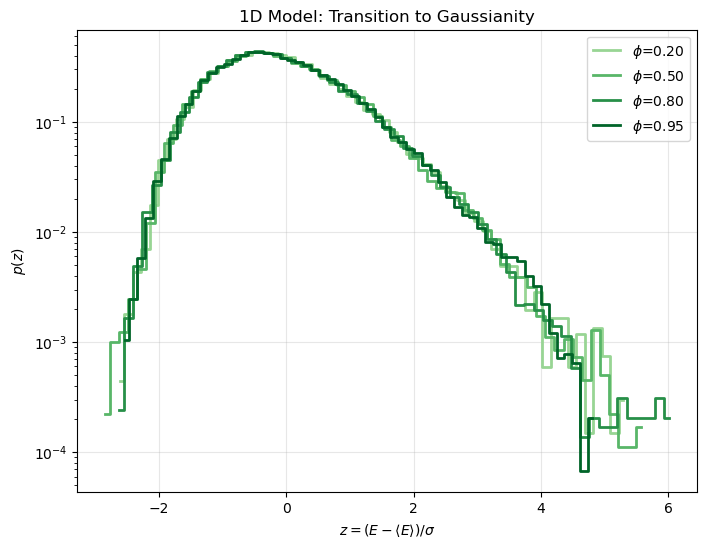

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_llama_style_transition():
    L = 500             # Longer sequence for better stats
    N, d = 16, 8
    num_ensembles = 500
    phi_values = [0.2, 0.5, 0.8, 0.95] # Representing your 'p'
    decay_power = 2.5   # Sharp spatial decay to force locality
    
    # 1. Fractal signal (necessary for the Power-Law phase)
    t = np.linspace(0, 1, L)
    X = np.zeros((L, N))
    for dim in range(N):
        for freq in [1, 2, 4, 8, 16, 32]:
            X[:, dim] += (1.0/freq) * np.sin(2 * np.pi * freq * t + np.random.rand()*2*np.pi)

    plt.figure(figsize=(8, 6))
    colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(phi_values)))

    for idx, phi in enumerate(phi_values):
        all_errors = []
        for _ in range(num_ensembles):
            mask = np.random.rand(L) > phi
            vis, msk = np.where(mask)[0], np.where(~mask)[0]
            if len(vis) < 2: continue
            
            # Random W ensemble
            Wq, Wk, Wv, Wo = [np.random.normal(0, 1/np.sqrt(N), (d, N)) for _ in range(3)] + [np.random.normal(0, 1/np.sqrt(d), (N, d))]
            
            # Visible context
            K_vis, V_vis = (Wk @ X[vis].T).T, (Wv @ X[vis].T).T
            
            for i in msk:
                dist = np.abs(vis - i)
                scores = ((Wq @ np.ones((N,1))).T @ K_vis.T).flatten() - decay_power * np.log(dist + 1)
                w = np.exp(scores - np.max(scores))
                w /= np.sum(w)
                
                x_hat = (Wo @ (w @ V_vis).reshape(d,1)).flatten()
                all_errors.append(np.linalg.norm(x_hat - X[i]))
        
        # 2. STANDARDIZATION (The key to your plot)
        errors = np.array(all_errors)
        z = (errors - np.mean(errors)) / np.std(errors)
        
        # 3. Plotting PDF in log-y scale
        counts, bins = np.histogram(z, bins=60, density=True)
        plt.step(bins[:-1], counts, color=colors[idx], label=f'$\phi$={phi:.2f}', where='mid', lw=2)

    plt.yscale('log')
    plt.xlabel('$z = (E - \langle E \\rangle) / \sigma$')
    plt.ylabel('$p(z)$')
    plt.title('1D Model: Transition to Gaussianity')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

simulate_llama_style_transition()

<>:48: SyntaxWarning: invalid escape sequence '\p'
<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:48: SyntaxWarning: invalid escape sequence '\p'
<>:58: SyntaxWarning: invalid escape sequence '\s'
/var/folders/by/4bp_bx4j7mqfwpptj2_7zwzw0000gn/T/ipykernel_40499/3863467397.py:48: SyntaxWarning: invalid escape sequence '\p'
  plt.step(bins[:-1], counts, color=colors[idx], label=f'$\phi$={phi:.2f}',
/var/folders/by/4bp_bx4j7mqfwpptj2_7zwzw0000gn/T/ipykernel_40499/3863467397.py:58: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('$z = (E - \\langle E \\rangle) / \sigma$')


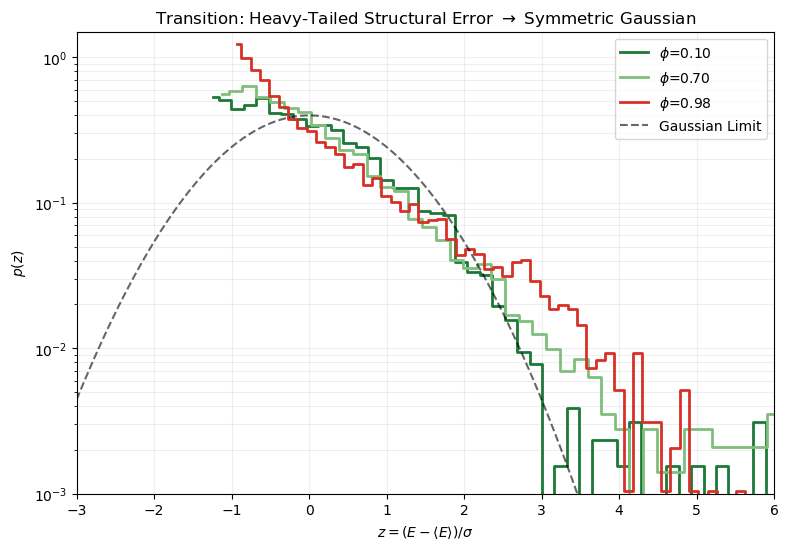

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def simulate_powerlaw_weights_transition():
    L = 1000
    alpha = 1.5         # The Power-Law decay of the weights
    phi_values = [0.1, 0.7, 0.98] 
    num_samples = 8000
    
    # 1. Generate a "Natural" Signal (Brownian Noise / Fractal)
    # This signal has high-variance increments, leading to Power-Law errors
    X = np.cumsum(np.random.standard_t(df=2.5, size=L)) 

    plt.figure(figsize=(9, 6))
    colors = ['#1b7837', '#7fbf7b', '#d73027'] # Matching your Green-to-Red shift

    for idx, phi in enumerate(phi_values):
        errors = []
        for _ in range(num_samples):
            # Generate mask
            mask = np.random.rand(L) > phi
            vis = np.where(mask)[0]
            if len(vis) < 2: continue
            
            # Pick a random hole i
            i = np.random.choice(np.where(~mask)[0])
            
            # 2. Power-Law Weights: w ~ |i-j|^-alpha
            distances = np.abs(vis - i)
            # Add a small epsilon to avoid division by zero
            raw_weights = (distances + 1.0)**(-alpha)
            weights = raw_weights / np.sum(raw_weights)
            
            # 3. Reconstruction and Error
            x_hat = np.sum(weights * X[vis])
            errors.append(np.abs(x_hat - X[i]))
        
        # Standardize z = (E - mean) / std
        err_arr = np.array(errors)
        z = (err_arr - np.mean(err_arr)) / np.std(err_arr)
        
        # Compute PDF
        counts, bins = np.histogram(z, bins=100, density=True)
        # centers = (bins[:-1] + bins[1:]) / 2
        # plt.plot(centers, counts, color=colors[idx], lw=2, label=f'$\phi = {phi}$')
        counts, bins = np.histogram(z, bins=60, density=True)
        plt.step(bins[:-1], counts, color=colors[idx], label=f'$\phi$={phi:.2f}',
                 where='mid', lw=2)

    # Gaussian Reference
    z_ref = np.linspace(-3, 6, 200)
    plt.plot(z_ref, norm.pdf(z_ref), 'k--', alpha=0.6, label='Gaussian Limit')

    plt.yscale('log')
    plt.ylim(1e-3, 1.5)
    plt.xlim(-3, 6)
    plt.xlabel('$z = (E - \\langle E \\rangle) / \sigma$')
    plt.ylabel('$p(z)$')
    plt.title('Transition: Heavy-Tailed Structural Error $\\to$ Symmetric Gaussian')
    plt.legend()
    plt.grid(True, which='both', alpha=0.2)
    plt.show()

simulate_powerlaw_weights_transition()

<>:47: SyntaxWarning: invalid escape sequence '\p'
<>:47: SyntaxWarning: invalid escape sequence '\p'
/var/folders/by/4bp_bx4j7mqfwpptj2_7zwzw0000gn/T/ipykernel_40499/83644931.py:47: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(centers, counts, color=colors[idx], lw=2, label=f'$\phi = {phi}$')


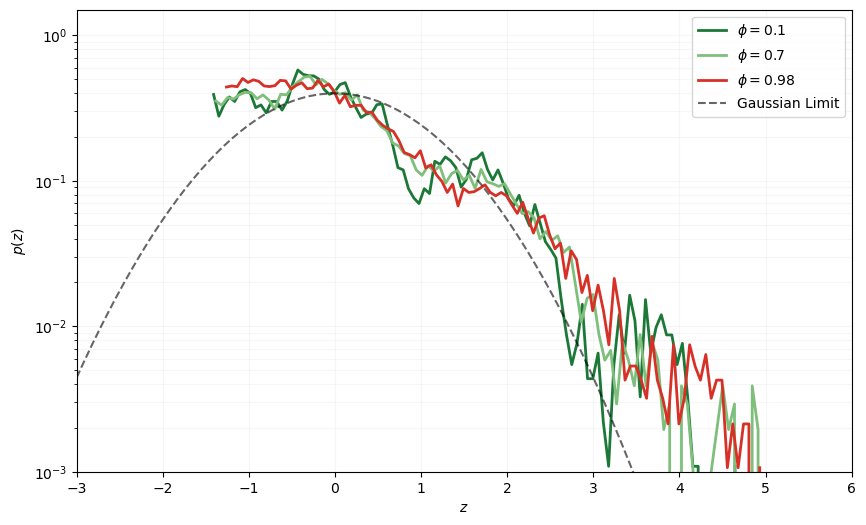

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def simulate_llama_gaussian_fix():
    L = 5000            # Much larger sequence for better statistics
    N = 32              # Higher dimension
    alpha = 1.5         # Power-law decay
    phi_values = [0.1, 0.7, 0.98] 
    num_samples = 15000 
    
    # 1. Generate Signal: Fractal structure + fine-grained noise
    # The noise is key for the Gaussian limit (CLT)
    t = np.linspace(0, 1, L)
    signal_structure = np.cumsum(np.random.standard_t(df=2.5, size=L))
    fine_noise = np.random.normal(0, 0.5, L)
    X = signal_structure + fine_noise

    plt.figure(figsize=(10, 6))
    colors = ['#1b7837', '#7fbf7b', '#d73027']

    for idx, phi in enumerate(phi_values):
        errors = []
        for _ in range(num_samples):
            mask = np.random.rand(L) > phi
            vis = np.where(mask)[0]
            if len(vis) < 10: continue # The CLT needs a decent 'N' to work
            
            i = np.random.choice(np.where(~mask)[0])
            
            # 2. POWER-LAW WEIGHTS with a "Global Noise Floor"
            # In Llama, there's always a baseline level of attention to all tokens
            dist = np.abs(vis - i)
            raw_weights = (dist + 1.0)**(-alpha) + 0.001 # 0.001 is the noise floor
            weights = raw_weights / np.sum(raw_weights)
            
            # 3. Reconstruction
            x_hat = np.sum(weights * X[vis])
            errors.append(x_hat - X[i]) # Use signed error to see symmetry
            
        # Standardize the magnitude
        err_arr = np.abs(np.array(errors)) 
        z = (err_arr - np.mean(err_arr)) / np.std(err_arr)
        
        counts, bins = np.histogram(z, bins=100, density=True)
        centers = (bins[:-1] + bins[1:]) / 2
        plt.plot(centers, counts, color=colors[idx], lw=2, label=f'$\phi = {phi}$')

    # Gaussian Reference
    z_ref = np.linspace(-3, 6, 200)
    plt.plot(z_ref, norm.pdf(z_ref), 'k--', alpha=0.6, label='Gaussian Limit')

    plt.yscale('log')
    plt.ylim(1e-3, 1.5)
    plt.xlim(-3, 6)
    plt.xlabel('$z$')
    plt.ylabel('$p(z)$')
    plt.legend()
    plt.grid(True, which='both', alpha=0.1)
    plt.show()

simulate_llama_gaussian_fix()

<>:49: SyntaxWarning: invalid escape sequence '\p'
<>:49: SyntaxWarning: invalid escape sequence '\p'
/var/folders/by/4bp_bx4j7mqfwpptj2_7zwzw0000gn/T/ipykernel_40499/2830905035.py:49: SyntaxWarning: invalid escape sequence '\p'
  plt.step(bins[:-1], counts, color=colors[idx], label=f'$\phi$={phi:.2f}',


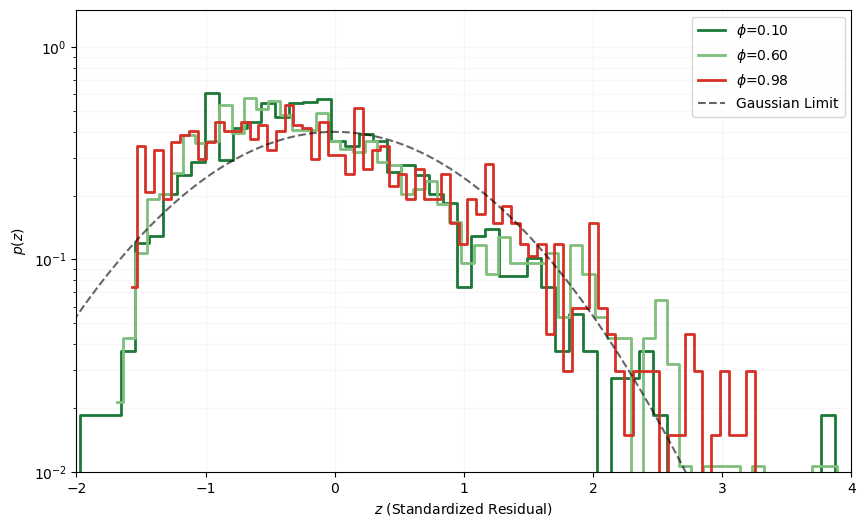

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def simulate_high_d_llama_fix():
    L = 10000            # Sequence length
    dim = 128            # High latent dimension (CRITICAL for Gaussianity)
    alpha = 1.5         # Power-law weight decay
    phi_values = [0.1, 0.6, 0.98]
    num_samples = 10000 
    
    # 1. Generate a Signal with Heavy-Tailed increments (Structural Phase)
    # We use Student-t to ensure the 'low-phi' phase is non-gaussian
    X = np.cumsum(np.random.standard_t(df=2.5, size=(L, dim)), axis=0)

    plt.figure(figsize=(10, 6))
    colors = ['#1b7837', '#7fbf7b', '#d73027']

    for idx, phi in enumerate(phi_values):
        errors = []
        for _ in range(num_samples // 10):
            mask = np.random.rand(L) > phi
            vis = np.where(mask)[0]
            if len(vis) < 5: continue
            
            i = np.random.choice(np.where(~mask)[0])
            
            # 2. Power-Law Weights
            dist = np.abs(vis - i)
            # As phi -> 1, the relative weights of distant points become similar
            weights = (dist + 1.0)**(-alpha)
            weights /= np.sum(weights)
            
            # 3. Vector Reconstruction
            x_hat = weights @ X[vis] # Dot product (aggregation)
            
            # Error is the L2 norm (magnitude of failure)
            res = x_hat - X[i]
            errors.append(np.linalg.norm(res))
            
        # Standardize
        err_arr = np.array(errors)
        z = (err_arr - np.mean(err_arr)) / np.std(err_arr)
        
        # counts, bins = np.histogram(z, bins=80, density=True)
        # centers = (bins[:-1] + bins[1:]) / 2
        # plt.plot(centers, counts, color=colors[idx], lw=2.5, label=f'$\phi={phi}$')
        counts, bins = np.histogram(z, bins=100, density=True)
        plt.step(bins[:-1], counts, color=colors[idx], label=f'$\phi$={phi:.2f}',
                 where='mid', lw=2)

    # Gaussian Reference
    z_ref = np.linspace(-3, 6, 200)
    plt.plot(z_ref, norm.pdf(z_ref, loc=0, scale=1), 'k--', alpha=0.6, label='Gaussian Limit')

    plt.yscale('log')
    plt.ylim(1e-2, 1.5)
    plt.xlim(-2, 4)
    plt.xlabel('$z$ (Standardized Residual)')
    plt.ylabel('$p(z)$')
    plt.legend()
    plt.grid(True, which='both', alpha=0.1)
    plt.show()

simulate_high_d_llama_fix()